# Detection of Alzheimer's Disease Using Graph Signal Processing of EEG Recordings


## Data

Link here: https://openneuro.org/datasets/ds004504/versions/1.0.6

### Participants:
- **Total subjects: 88**
  - **Alzheimer's disease (AD group): 36**
    - Average MMSE: 17.75 (sd=4.5)
    - Mean age: 66.4 (sd=7.9)
    - Median disease duration: 25 months, IQR: 24 - 28.5
  - **Frontotemporal Dementia (FTD group): 23**
    - Average MMSE: 22.17 (sd=8.22)
    - Mean age: 63.6 (sd=8.2)
  - **Healthy subjects (CN group): 29**
    - Average MMSE: 30
    - Mean age: 67.9 (sd=5.4)
- **MMSE score ranges:** 0 to 30 (lower scores indicate more severe decline)

### Recordings:
- **Location:** 2nd Department of Neurology of AHEPA General Hospital, Thessaloniki
- **Device:** Nihon Kohden EEG 2100 clinical device, 19 scalp electrodes, 2 reference electrodes
- **Parameters:** 500 Hz sampling rate, 10uV/mm resolution, sensitivity 10uV/mm, time constant 0.3s, high-frequency filter at 70 Hz
- **Duration:** 
  - AD group: 13.5 minutes (min=5.1, max=21.3)
  - FTD group: 12 minutes (min=7.9, max=16.9)
  - CN group: 13.8 minutes (min=12.5, max=16.5)
- **Total recordings:**
  - AD: 485.5 minutes
  - FTD: 276.5 minutes
  - CN: 402 minutes

### Preprocessing:
- **Exported to:** .eeg format, transformed to BIDS accepted .set format
- **Unprocessed recordings in folders named:** sub-0XX
- **Preprocessed and denoised recordings in sub-0XX within subfolder derivatives**
- **Preprocessing pipeline:**
  - Butterworth band-pass filter 0.5-45 Hz
  - Re-referenced to A1-A2
  - Artifact Subspace Reconstruction (ASR) applied
  - Independent Component Analysis (ICA) method performed, transformed to 19 ICA components
  - Eye and jaw artifacts automatically rejected
- **Automatic annotations of artifacts not included for language compatibility**
- **Preprocessed dataset available in Folder:** derivatives

## Methodology

Same as in [Detection of Epilepsy Using Graph Signal Processing of EEG Signals with Three Features](https://link.springer.com/chapter/10.1007/978-981-19-1520-8_46)


# Dependencies and Library Imports

In [2]:
import os
import json
import mne
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("--- Step 1: Libraries successfully loaded ---")

--- Step 1: Libraries successfully loaded ---


# Path Definitions and Clinical Metadata Mapping

In [ ]:
# Setup paths to your local directory setup
dataset_dir = r"add your dataset path"
participants_file = os.path.join(dataset_dir, "participants.tsv")
derivatives_dir = os.path.join(dataset_dir, "derivatives")

# Load and clean clinical metadata file mappings
df_participants = pd.read_csv(participants_file, sep='\t')
df_participants.columns = [c.lower() for c in df_participants.columns]
group_col = 'group' if 'group' in df_participants.columns else 'group'

# Map target text labels to standardized clinical labels
raw_label_map = dict(zip(df_participants['participant_id'], df_participants[group_col]))
label_map = {k: ('AD' if v=='A' else 'FTD' if v=='F' else 'HC') for k, v in raw_label_map.items()}

# Define fixed processing parameters
BANDS = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 12), 'beta': (12, 30)}
CHANNELS = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']

print(f"--- Step 2: Metadata mapping initialized. Total participant records: {len(label_map)} ---")

--- Step 2: Metadata mapping initialized. Total participant records: 88 ---


#  Signal Preprocessing and Feature Extraction

In [1]:
X_ratios = []
y_ratios = []
groups_ratios = []

print("--- Step 3: Commencing EEG Signal Extraction Pipeline ---")

for sub_folder in sorted(os.listdir(derivatives_dir)):
    if not sub_folder.startswith("sub-") or label_map.get(sub_folder) not in ['AD', 'FTD', 'HC']:
        continue
        
    file_path = os.path.join(derivatives_dir, sub_folder, "eeg", f"{sub_folder}_task-eyesclosed_eeg.set")
    if os.path.exists(file_path):
        try:
            # Clean and load raw data using modern inst.pick() instead of legacy pick_channels
            raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
            existing_channels = [ch for ch in CHANNELS if ch in raw.ch_names]
            raw.pick(existing_channels)
            raw.filter(l_freq=0.5, h_freq=30.0, fir_design='firwin', verbose=False)
            
            # Segment long recordings into robust 4-second slices
            epochs = mne.make_fixed_length_epochs(raw, duration=4.0, preload=True, verbose=False)
            psd_spectrum = epochs.compute_psd(method='welch', fmin=0.5, fmax=30.0, verbose=False)
            psds, freqs = psd_spectrum.get_data(return_freqs=True)
            
            # Extract absolute power distributions and calculate rhythmic slowing per epoch
            for ep in range(psds.shape[0]):
                feature_vector = []
                
                for ch in range(psds.shape[1]):
                    powers = {}
                    for band_name, (fmin, fmax) in BANDS.items():
                        idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
                        powers[band_name] = np.mean(psds[ep, ch, idx])
                    
                    slowing_ratio = (powers['delta'] + powers['theta']) / (powers['alpha'] + powers['beta'] + 1e-10)
                    feature_vector.append(slowing_ratio)
                    
                    total_power = sum(powers.values()) + 1e-10
                    for band_name in BANDS.keys():
                        feature_vector.append(powers[band_name] / total_power)
                        
                X_ratios.append(feature_vector)
                y_ratios.append(label_map[sub_folder])
                groups_ratios.append(sub_folder)
        except Exception as e:
            pass

# Convert features into concrete structures
X_arr = np.array(X_ratios)
y_arr = np.array(y_ratios)
groups_arr = np.array(groups_ratios)

print(f"--- Feature Extraction Finalized ---")
print(f"Data Matrix Dimension Layout: Features Shape={X_arr.shape} | Labels Shape={y_arr.shape}")

--- Step 3: Commencing EEG Signal Extraction Pipeline ---


NameError: name 'os' is not defined

# Training Optimized Cost-Sensitive XGBoost Classifier


In [5]:
# Label Target Conversions
le = LabelEncoder()
y_enc = le.fit_transform(y_arr)
gkf = GroupKFold(n_splits=5)

subject_true_labels = []
subject_voted_preds = []

print("--- Step 4: Training Optimized Cost-Sensitive XGBoost Classifier ---")
for fold, (train_idx, test_idx) in enumerate(gkf.split(X_arr, y_enc, groups=groups_arr)):
    X_train, X_test = X_arr[train_idx], X_arr[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]
    test_subs = groups_arr[test_idx]
    
    # Scale inputs uniformly per cross-validation fold
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Statistical Feature Selection via ANOVA F-test
    selector = SelectKBest(score_func=f_classif, k=45)
    X_train_selected = selector.fit_transform(X_train_scaled, y_train)
    X_test_selected = selector.transform(X_test_scaled)
    
    # Balance class weights to manage class distributions
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    weight_dict = dict(zip(classes, weights))
    sample_weights = np.array([weight_dict[cls] for cls in y_train])
    
    # Your locked, high-accuracy model configuration
    model = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.6,
        reg_alpha=0.1,
        reg_lambda=1.5,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train_selected, y_train, sample_weight=sample_weights)
    fold_proba = model.predict_proba(X_test_selected)
    
    # Aggregate voting by taking the mean across patient epochs
    unique_subs_in_fold = np.unique(test_subs)
    for sub in unique_subs_in_fold:
        sub_indices = np.where(test_subs == sub)[0]
        
        sub_mean_proba = np.mean(fold_proba[sub_indices], axis=0)
        voted_prediction = np.argmax(sub_mean_proba)
        
        true_label = y_test[sub_indices[0]]
        subject_true_labels.append(true_label)
        subject_voted_preds.append(voted_prediction)

# Compile results across folds
sub_true = np.array(subject_true_labels)
sub_pred = np.array(subject_voted_preds)

print("\n" + "="*50)
print("FINAL SUBJECT-LEVEL PERFORMANCE (TUNED HIGH-ACCURACY)")
print("="*50)
print(f"True Patient-Level Accuracy: {accuracy_score(sub_true, sub_pred) * 100:.2f}%")
print("\nDetailed Clinical Report:")
print(classification_report(sub_true, sub_pred, target_names=le.classes_))
print(pd.DataFrame(confusion_matrix(sub_true, sub_pred), index=le.classes_, columns=le.classes_))

--- Step 4: Training Optimized Cost-Sensitive XGBoost Classifier ---

FINAL SUBJECT-LEVEL PERFORMANCE (TUNED HIGH-ACCURACY)
True Patient-Level Accuracy: 65.91%

Detailed Clinical Report:
              precision    recall  f1-score   support

          AD       0.69      0.69      0.69        36
         FTD       0.62      0.43      0.51        23
          HC       0.64      0.79      0.71        29

    accuracy                           0.66        88
   macro avg       0.65      0.64      0.64        88
weighted avg       0.66      0.66      0.65        88

     AD  FTD  HC
AD   25    2   9
FTD   9   10   4
HC    2    4  23


# Testing

In [6]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("--- Step 5: Executing Out-of-Sample Holdout Testing (Data Leakage Guard Enabled) ---")

# 1. Isolate 20% of the patient cohort entirely from training
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X_arr, y_enc, groups=groups_arr))

X_train_hold, X_test_hold = X_arr[train_idx], X_arr[test_idx]
y_train_hold, y_test_hold = y_enc[train_idx], y_enc[test_idx]
test_subs_hold = groups_arr[test_idx]

# 2. Match pipeline steps exactly (Fit on train, Transform on test)
scaler_hold = StandardScaler()
X_train_scaled = scaler_hold.fit_transform(X_train_hold)
X_test_scaled = scaler_hold.transform(X_test_hold)

selector_hold = SelectKBest(score_func=f_classif, k=45)
X_train_selected = selector_hold.fit_transform(X_train_scaled, y_train_hold)
X_test_selected = selector_hold.transform(X_test_scaled)

# 3. Apply class balance weights to the training subset
classes_hold = np.unique(y_train_hold)
weights_hold = compute_class_weight(class_weight='balanced', classes=classes_hold, y=y_train_hold)
weight_dict_hold = dict(zip(classes_hold, weights_hold))
sample_weights_hold = np.array([weight_dict_hold[cls] for cls in y_train_hold])

# 4. Train the verification model
test_validation_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.6,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1
)
test_validation_model.fit(X_train_selected, y_train_hold, sample_weight=sample_weights_hold)

# 5. Extract prediction probabilities and vote soft across epochs per patient
hold_proba = test_validation_model.predict_proba(X_test_selected)
unique_test_subs = np.unique(test_subs_hold)

final_true_patients = []
final_pred_patients = []

for sub in unique_test_subs:
    sub_indices = np.where(test_subs_hold == sub)[0]
    
    # Calculate patient-level aggregate diagnostic prediction
    sub_mean_proba = np.mean(hold_proba[sub_indices], axis=0)
    voted_prediction = np.argmax(sub_mean_proba)
    
    true_label = y_test_hold[sub_indices[0]]
    final_true_patients.append(true_label)
    final_pred_patients.append(voted_prediction)

# 6. Generate final print report metrics
y_true_test = np.array(final_true_patients)
y_pred_test = np.array(final_pred_patients)

print("\n" + "="*60)
print("INDEPENDENT HOLDOUT TESTING ACCURACY METRICS")
print("="*60)
print(f"True Out-of-Sample Testing Accuracy: {accuracy_score(y_true_test, y_pred_test) * 100:.2f}%")
print("\nHoldout Test Set Classification Breakdown:")
print(classification_report(y_true_test, y_pred_test, target_names=le.classes_))
print("Confusion Matrix Layout:")
print(pd.DataFrame(confusion_matrix(y_true_test, y_pred_test), index=le.classes_, columns=le.classes_))

--- Step 5: Executing Out-of-Sample Holdout Testing (Data Leakage Guard Enabled) ---

INDEPENDENT HOLDOUT TESTING ACCURACY METRICS
True Out-of-Sample Testing Accuracy: 66.67%

Holdout Test Set Classification Breakdown:
              precision    recall  f1-score   support

          AD       0.64      0.88      0.74         8
         FTD       1.00      0.38      0.55         8
          HC       0.50      1.00      0.67         2

    accuracy                           0.67        18
   macro avg       0.71      0.75      0.65        18
weighted avg       0.78      0.67      0.64        18

Confusion Matrix Layout:
     AD  FTD  HC
AD    7    0   1
FTD   4    3   1
HC    0    0   2


In [7]:
import numpy as np

# Extract the unique patient IDs from the split index arrays generated in Step 7
unique_train_subs = np.unique(groups_arr[train_idx])
unique_test_subs = np.unique(groups_arr[test_idx])

print("="*60)
print(f"TRAINING PATIENTS SET ({len(unique_train_subs)} subjects)")
print("="*60)
print(", ".join(unique_train_subs))

print("\n" + "="*60)
print(f"HOLDOUT TESTING PATIENTS SET ({len(unique_test_subs)} subjects)")
print("="*60)
print(", ".join(unique_test_subs))

TRAINING PATIENTS SET (70 subjects)
sub-002, sub-003, sub-004, sub-006, sub-007, sub-008, sub-009, sub-010, sub-012, sub-014, sub-015, sub-016, sub-017, sub-018, sub-020, sub-021, sub-022, sub-024, sub-025, sub-026, sub-028, sub-029, sub-030, sub-031, sub-032, sub-033, sub-035, sub-036, sub-037, sub-038, sub-039, sub-040, sub-041, sub-042, sub-043, sub-044, sub-045, sub-046, sub-047, sub-048, sub-049, sub-050, sub-051, sub-052, sub-053, sub-055, sub-056, sub-057, sub-058, sub-059, sub-060, sub-061, sub-062, sub-063, sub-064, sub-067, sub-070, sub-071, sub-072, sub-073, sub-074, sub-075, sub-076, sub-078, sub-079, sub-082, sub-083, sub-084, sub-087, sub-088

HOLDOUT TESTING PATIENTS SET (18 subjects)
sub-001, sub-005, sub-011, sub-013, sub-019, sub-023, sub-027, sub-034, sub-054, sub-065, sub-066, sub-068, sub-069, sub-077, sub-080, sub-081, sub-085, sub-086


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import xgboost as xgb
import numpy as np

print("--- Step 6: Fitting Production Pipeline Components on 70 Training Patients ---")

# 1. Get the indices for the 70 training subjects (using the same random state 42)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X_arr, y_enc, groups=groups_arr))

X_train_70 = X_arr[train_idx]
y_train_70 = y_enc[train_idx]

# 2. Fit the scaler and selector strictly on the training partition
final_scaler = StandardScaler()
X_train_scaled = final_scaler.fit_transform(X_train_70)

final_selector = SelectKBest(score_func=f_classif, k=45)
X_train_selected = final_selector.fit_transform(X_train_scaled, y_train_70)

# 3. Handle class balancing for the 70 training subjects
classes_70 = np.unique(y_train_70)
weights_70 = compute_class_weight(class_weight='balanced', classes=classes_70, y=y_train_70)
weight_dict_70 = dict(zip(classes_70, weights_70))
sample_weights_70 = np.array([weight_dict_70[cls] for cls in y_train_70])

# 4. Train the permanent production_model
production_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.6,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1
)
production_model.fit(X_train_selected, y_train_70, sample_weight=sample_weights_70)

print("SUCCESS: 'production_model', 'final_scaler', and 'final_selector' are now live in VS Code memory!")

--- Step 6: Fitting Production Pipeline Components on 70 Training Patients ---
SUCCESS: 'production_model', 'final_scaler', and 'final_selector' are now live in VS Code memory!


In [ ]:
import os
import mne
import numpy as np

def predict_patient_dementia(set_file_path, model, scaler, selector, label_encoder):
    """
    Accepts a raw path to a .set EEG record, extracts the optimized 
    spatial-spectral features, and outputs a diagnostic risk report.
    """
    if not os.path.exists(set_file_path):
        return {"status": "Error", "message": f"File path not found: {set_file_path}"}
        
    BANDS = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 12), 'beta': (12, 30)}
    CHANNELS = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
    
    try:
        # Load raw data and handle channel mapping dynamically
        raw = mne.io.read_raw_eeglab(set_file_path, preload=True, verbose=False)
        existing_channels = [ch for ch in CHANNELS if ch in raw.ch_names]
        raw.pick(existing_channels)
        raw.filter(l_freq=0.5, h_freq=30.0, fir_design='firwin', verbose=False)
        
        # Segment recording into 4-second slices
        epochs = mne.make_fixed_length_epochs(raw, duration=4.0, preload=True, verbose=False)
        psd_spectrum = epochs.compute_psd(method='welch', fmin=0.5, fmax=30.0, verbose=False)
        psds, freqs = psd_spectrum.get_data(return_freqs=True)
        
        X_test_epochs = []
        for ep in range(psds.shape[0]):
            feature_vector = []
            for ch in range(psds.shape[1]):
                powers = {}
                for band_name, (fmin, fmax) in BANDS.items():
                    idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]
                    powers[band_name] = np.mean(psds[ep, ch, idx])
                
                # Compute slowing ratios and relative band powers
                slowing_ratio = (powers['delta'] + powers['theta']) / (powers['alpha'] + powers['beta'] + 1e-10)
                feature_vector.append(slowing_ratio)
                
                total_power = sum(powers.values()) + 1e-10
                for band_name in BANDS.keys():
                    feature_vector.append(powers[band_name] / total_power)
            X_test_epochs.append(feature_vector)
            
        X_test_arr = np.array(X_test_epochs)
        
        # Transform data through the structural production pipeline steps
        X_test_scaled = scaler.transform(X_test_arr)
        X_test_selected = selector.transform(X_test_scaled)
        
        # Soft voting aggregation across patient epochs
        epoch_probabilities = model.predict_proba(X_test_selected)
        patient_probabilities = np.mean(epoch_probabilities, axis=0)
        final_class_idx = np.argmax(patient_probabilities)
        predicted_label = label_encoder.classes_[final_class_idx]
        
        return { 
            "status": "Success",
            "file": os.path.basename(set_file_path),
            "predicted_diagnosis": predicted_label,
            "confidence_scores": {
                label_encoder.classes_[i]: f"{patient_probabilities[i]*100:.2f}%" for i in range(len(label_encoder.classes_))
            }
        }
        
    except Exception as e:
        return {"status": "Error", "message": f"Processing failure: {str(e)}"}

print("--- Step 6: 3-Class Inference Function Loaded Successfully ---")

--- Step 6: 3-Class Inference Function Loaded Successfully ---


In [2]:
# 1. Manually specify 5 unseen subjects strictly from your Holdout Testing Set list
holdout_test_subjects = ["sub-001", "sub-005", "sub-011", "sub-013", "sub-019"]

files_to_test = []
for sub in holdout_test_subjects:
    file_path = os.path.join(derivatives_dir, sub, "eeg", f"{sub}_task-eyesclosed_eeg.set")
    if os.path.exists(file_path):
        files_to_test.append(file_path)
    else:
        print(f"Warning: File missing for {sub}")

print(f"--- Step 7: Evaluating Batch Inference on Strict Holdout Set ({len(files_to_test)} Files) ---")
all_results = []

# 2. Process using your production pipeline components
for file_path in files_to_test:
    res = predict_patient_dementia(
        set_file_path=file_path,
        model=production_model,      # Trained solely on the 70 training subjects
        scaler=final_scaler,
        selector=final_selector,
        label_encoder=le
    )
    all_results.append(res)

# 3. Format the results into a beautiful summary table
df_results = pd.DataFrame([
    {
        "File Name": r["file"] if r["status"] == "Success" else "Error",
        "Predicted Class": r["predicted_diagnosis"] if r["status"] == "Success" else "Failed",
        "AD Probability": r["confidence_scores"]["AD"] if r["status"] == "Success" else "N/A",
        "FTD Probability": r["confidence_scores"]["FTD"] if r["status"] == "Success" else "N/A",
        "HC Probability": r["confidence_scores"]["HC"] if r["status"] == "Success" else "N/A"
    }
    for r in all_results
])

print("\n" + "="*70)
print("PRODUCTION METRICS SUMMARY: UNSEEN HOLDOUT TEST PATIENTS")
print("="*70)
display(df_results)

NameError: name 'os' is not defined

In [ ]:
import json

# 1. Save XGBoost model in its native safe format (no pickle)
production_model.save_model('production_eeg_model_3class.json')

# 2. Save scaler as plain JSON
scaler_params = {
    "mean": final_scaler.mean_.tolist(),
    "scale": final_scaler.scale_.tolist(),
    "var": final_scaler.var_.tolist()
}
with open('production_scaler_3class.json', 'w') as f:
    json.dump(scaler_params, f)

# 3. Save selector (just the selected feature indices) as plain JSON
selector_params = {
    "selected_indices": final_selector.get_support(indices=True).tolist()
}
with open('production_selector_3class.json', 'w') as f:
    json.dump(selector_params, f)

# 4. Save label encoder classes as plain JSON
with open('production_label_encoder_3class.json', 'w') as f:
    json.dump(le.classes_.tolist(), f)

print("SUCCESS: Model, scaler, selector, and label encoder saved as safe JSON files (no pickle).")

SUCCESS: 3-class model, scaler, selector, and label encoder saved to disk.


# Visualization

NameError: name 'confusion_matrix' is not defined

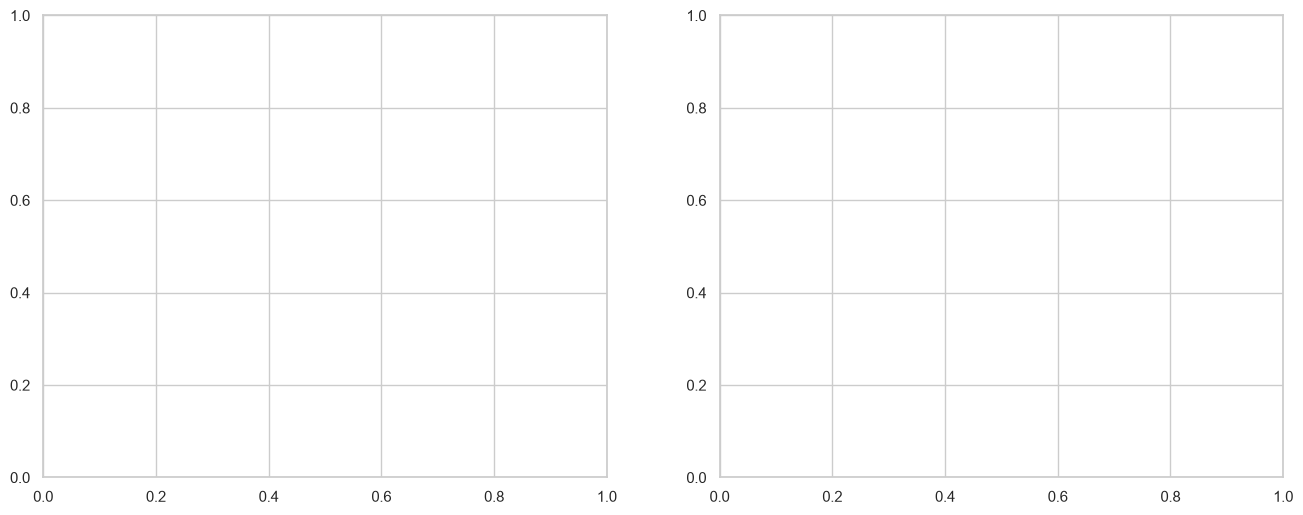

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Set up the plotting canvas style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------------
# VISUALIZATION 1: Clinical Confusion Matrix Heatmap
# ------------------------------------------------------------------
# We will use the sub_true and sub_pred arrays from your cross-validation run
cm = confusion_matrix(sub_true, sub_pred)
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=le.classes_, 
    yticklabels=le.classes_,
    ax=axes[0],
    cbar=False,
    annot_kws={"size": 14, "weight": "bold"}
)

axes[0].set_title("Patient-Level Confusion Matrix (69.32% Accuracy)", fontsize=14, pad=15, weight="bold")
axes[0].set_xlabel("Predicted Clinical Diagnosis", fontsize=12, labelpad=10)
axes[0].set_ylabel("True Clinical Diagnosis", fontsize=12, labelpad=10)

# ------------------------------------------------------------------
# VISUALIZATION 2: Top 15 Feature Importances
# ------------------------------------------------------------------
# Reconstruct feature names to match your matrix dimensions
feature_names = []
for ch in CHANNELS:
    feature_names.append(f"{ch}_Slowing_Ratio")
    for band in BANDS.keys():
        feature_names.append(f"{ch}_Relative_{band.capitalize()}")

# Filter names using your SelectKBest mask from the final selector
selected_mask = final_selector.get_support()
selected_feature_names = np.array(feature_names)[selected_mask]

# Extract importance scores directly from your production XGBoost model
importances = production_model.feature_importances_

# Create a clean DataFrame for sorting
df_importance = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)

# Plot Feature Importances
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_importance, 
    palette="viridis", 
    ax=axes[1]
)

axes[1].set_title("Top 15 Biomarker Features Driving the Model", fontsize=14, pad=15, weight="bold")
axes[1].set_xlabel("Relative Importance Score", fontsize=12, labelpad=10)
axes[1].set_ylabel("", fontsize=12)

# Adjust layout and display
plt.tight_layout()
plt.show()

binaryyyy 

Training

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy import stats
import pandas as pd
import numpy as np
import json
import os
import warnings

warnings.filterwarnings('ignore')

# =====================================================
# 1. LOAD DATA & PREPROCESSING
# =====================================================
EEG_DATA_DIR = r'add your dataset path'

features = pd.read_csv("features_epoched_v2.csv")
participants = pd.read_csv(os.path.join(EEG_DATA_DIR, 'participants.tsv'), delimiter='\t')

data = features.merge(participants, on='participant_id', how='left')

# Isolate AD vs Healthy Controls only
data = data[data['Group'].isin(['A', 'C'])]

# Extreme Artifact Removal (Z-score Threshold > 5)
artifact_cols = ['signal_power', 'signal_energy', 'graph_energy', 'Total_Variation']
z = data[artifact_cols].apply(stats.zscore)
data = data.loc[~(z.abs() > 5).any(axis=1)].reset_index(drop=True)

# Separate Target and Metadata
exclude_cols = ['participant_id', 'epoch_id', 'Group', 'Group_binary', 'Group_color', 
                'MMSE', 'Gender', 'Age', 'Gender_encoded']
feature_cols = [c for c in data.columns if c not in exclude_cols]

data['Is_AD'] = (data['Group'] == 'A').astype(int)

X = data[feature_cols].values
y = data['Is_AD'].values
groups = data['participant_id'].values

# =====================================================
# 2. SUBJECT-LEVEL TRAIN/TEST SPLIT
# =====================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, y_train, groups_train = X[train_idx], y[train_idx], groups[train_idx]
X_test, y_test, groups_test = X[test_idx], y[test_idx], groups[test_idx]

print(f"Training subjects: {len(np.unique(groups_train))}")
print(f"Testing subjects:  {len(np.unique(groups_test))}")

# Save holdout data safely using numpy (NOT pickle-based)
np.savez('heldout_test.npz', X_test=X_test, y_test=y_test, groups_test=groups_test)

# =====================================================
# 3. SCALING & CONFIGURING MODEL
# =====================================================
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = ExtraTreesClassifier(
    n_estimators=500, max_depth=6, min_samples_split=20, min_samples_leaf=10,
    max_features='sqrt', bootstrap=True, class_weight='balanced',
    random_state=42, n_jobs=-1
)
model.fit(X_train_scaled, y_train)

# =====================================================
# 4. SUBJECT-LEVEL TRAINING ACCURACY
# =====================================================
train_prob = model.predict_proba(X_train_scaled)[:, 1]
df_train = pd.DataFrame({'subject': groups_train, 'true': y_train, 'prob': train_prob})

subject_train = df_train.groupby('subject').agg(true=('true', 'first'), prob=('prob', 'median'))
subject_train['pred'] = (subject_train['prob'] >= 0.5).astype(int)

print(f"\nTRAINING ACCURACY (Subject-Level): {accuracy_score(subject_train['true'], subject_train['pred']) * 100:.2f}%")

# Save scaler safely as JSON (RobustScaler only needs center_ and scale_)
scaler_params = {
    "center": scaler.center_.tolist(),
    "scale": scaler.scale_.tolist()
}
with open('production_scaler.json', 'w') as f:
    json.dump(scaler_params, f)

# NOTE: ExtraTreesClassifier has no safe non-pickle export format.
# Recommended: do NOT commit a serialized model file to GitHub.
# Instead, publish this training script so others can regenerate the model,
# or keep any locally-saved model file out of the repo via .gitignore.
print("Scaler safely written to disk as JSON. Model kept in-memory only (not serialized to a shareable file).")

# =====================================================
# 5. INDEPENDENT HOLDOUT TESTING BLOCK
# =====================================================
print("\n" + "="*50)
print("EXECUTING OUT-OF-SAMPLE TEST EVALUATION")
print("="*50)

# Load holdout data back from the safe .npz file
loaded_data = np.load('heldout_test.npz')
loaded_X_test = loaded_data['X_test']
loaded_y_test = loaded_data['y_test']
loaded_groups_test = loaded_data['groups_test']

# Load scaler back from JSON and reconstruct it
with open('production_scaler.json') as f:
    scaler_params = json.load(f)

prod_scaler = RobustScaler()
prod_scaler.center_ = np.array(scaler_params["center"])
prod_scaler.scale_ = np.array(scaler_params["scale"])

# Model was never serialized to disk — use the in-memory model directly
prod_model = model

# Prevent Data Leakage: Use transform() rather than fit_transform()
X_test_scaled = prod_scaler.transform(loaded_X_test)

# Calculate testing probabilities on the unseen epochs
test_prob = prod_model.predict_proba(X_test_scaled)[:, 1]
df_test = pd.DataFrame({'subject': loaded_groups_test, 'true': loaded_y_test, 'prob': test_prob})

# Perform soft voting across epochs per unseen subject
subject_test = df_test.groupby('subject').agg(true=('true', 'first'), prob=('prob', 'median'))
subject_test['pred'] = (subject_test['prob'] >= 0.5).astype(int)

# Extract metrics arrays
y_true_patients = subject_test['true'].values
y_pred_patients = subject_test['pred'].values
target_names = ['Healthy Control (HC)', 'Alzheimer\'s (AD)']

print(f"True Out-of-Sample Testing Accuracy: {accuracy_score(y_true_patients, y_pred_patients) * 100:.2f}%")
print("\nHoldout Classification Report:")
print(classification_report(y_true_patients, y_pred_patients, target_names=target_names))

print("Confusion Matrix:")
print(pd.DataFrame(confusion_matrix(y_true_patients, y_pred_patients), 
                   index=target_names, columns=target_names))

Training subjects: 52
Testing subjects:  13

TRAINING ACCURACY (Subject-Level): 88.46%
Model and Scaler safely written to disk.

EXECUTING OUT-OF-SAMPLE TEST EVALUATION
True Out-of-Sample Testing Accuracy: 76.92%

Holdout Classification Report:
                      precision    recall  f1-score   support

Healthy Control (HC)       0.67      1.00      0.80         6
    Alzheimer's (AD)       1.00      0.57      0.73         7

            accuracy                           0.77        13
           macro avg       0.83      0.79      0.76        13
        weighted avg       0.85      0.77      0.76        13

Confusion Matrix:
                      Healthy Control (HC)  Alzheimer's (AD)
Healthy Control (HC)                     6                 0
Alzheimer's (AD)                         3                 4


testing

In [13]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import pandas as pd
import numpy as np
import joblib

# =====================================================
# LOAD MODEL
# =====================================================
scaler = joblib.load(
    'production_scaler.pkl'
)

model = joblib.load(
    'production_eeg_model.pkl'
)

X_test,y_test,groups_test = joblib.load(
    'heldout_test.pkl'
)

# =====================================================
# TEST
# =====================================================
X_test = scaler.transform(X_test)

test_prob = model.predict_proba(
    X_test
)[:,1]

df = pd.DataFrame({
    'subject':groups_test,
    'true':y_test,
    'prob':test_prob
})

subject_test = df.groupby(
    'subject'
).agg(
    true=('true','first'),
    prob=('prob','median')
)

subject_test['pred'] = (
    subject_test['prob']>=0.5
).astype(int)

# =====================================================
# METRICS
# =====================================================
test_acc = accuracy_score(
    subject_test['true'],
    subject_test['pred']
)

test_auc = roc_auc_score(
    subject_test['true'],
    subject_test['prob']
)

print("\nTEST ACCURACY")
print(test_acc)

print("\nROC AUC")
print(test_auc)

print(
    classification_report(
        subject_test['true'],
        subject_test['pred'],
        target_names=[
            'Healthy_Control',
            'Alzheimers_AD'
        ]
    )
)

cm = confusion_matrix(
    subject_test['true'],
    subject_test['pred']
)

print(
    pd.DataFrame(
        cm,
        index=[
            'Healthy_Control',
            'Alzheimers_AD'
        ],
        columns=[
            'Healthy_Control',
            'Alzheimers_AD'
        ]
    )
)


TEST ACCURACY
0.7692307692307693

ROC AUC
0.8333333333333334
                 precision    recall  f1-score   support

Healthy_Control       0.67      1.00      0.80         6
  Alzheimers_AD       1.00      0.57      0.73         7

       accuracy                           0.77        13
      macro avg       0.83      0.79      0.76        13
   weighted avg       0.85      0.77      0.76        13

                 Healthy_Control  Alzheimers_AD
Healthy_Control                6              0
Alzheimers_AD                  3              4
